### 서울시 행정동별 요양시설 유효공급 격차 ⑦ 미래 수요

> 검토 정정: 미래 값은 2024년 인정률·공급·목표 고정 시나리오다. 기존 48곳은 순차 배치의 실행 가능 해로 최소를 증명하지 않았다. 2019→2024 인구 역검증과 동별 순이동 시나리오는 아직 수행하지 않은 후속 과제다.

보고서 문장은 독립 재계산 산출물의 입력 해시가 일치할 때만 표시한다. 자료를 바꾸면 `python 검토_재계산.py`를 실행한다.


지금의 공급이 그대로라면 5년 뒤(2029), 10년 뒤(2034)에 어느 동이 얼마나 부족해지는지 계산한다. 동별 고령인구는 코호트 방식으로 늙혀 추정하고, 인정률과 공급은 2024년 수준으로 고정한다.

$$P_{i,\,a+5}(t+5) = P_{i,a}(t) \times s_a$$

### 1. 분석 기준

- 기준 인구: 행정안전부 주민등록인구(2024-07-31), 서울·경기·인천 전체 행정동의 성별 5세 연령군(01 노트북)
- 생존비 $s_a$: 통계청 시도별 간이생명표(2023, KOSIS `DT_1B44`)의 정지인구로 $s_a = {}_5L_{a+5} / {}_5L_a$. 시도·성별로 따로 적용한다. 95세 이상은 $T_{100} / T_{95}$를 95~99세와 100세 이상을 합한 인구에 적용해 100세 이상으로 보낸다.
- 보정: 코호트 방식은 전입·전출과 사망률 개선을 반영하지 못한다. 통계청 시도별 장래인구추계(2022년 기준 중위 추계, KOSIS `DT_1BPB001`)의 시도·성·5세 연령군별 **2024년 대비 증가율**을 2024년 주민등록인구에 곱한 값을 목표 합계로 두고, 동별 코호트 값을 시도·성·연령군 안에서 비례 조정한다. 추계인구(외국인 포함 상주인구)와 주민등록인구(외국인 제외)는 정의가 달라 수준 대신 증가율로 맞춘다.
- 수요: 02 노트북의 2024년 서울 연령별 1~2등급 인정률(버전 A)을 그대로 곱한다.
- 공급과 E2SFCA: 03·04 노트북과 같다(반경 5km, 정원 × q, 시설 고정).
- 기준값: **2024년 서울 동 중앙값(반경 5km, 100명당 67.5석)으로 고정**한다. 해마다 중앙값을 다시 구하면 수요가 늘어도 모든 동이 함께 나빠져 격차가 드러나지 않는다.
- KOSIS 인증키는 저장소 루트 `.env`의 `KOSIS_API_KEY`에서 읽고(`config.kosis_key()`), 받은 표는 `assets/`에 CSV로 캐시한다. 키 값은 출력하거나 파일에 남기지 않는다.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display, Markdown

import config as C
import e2sfca as E

pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

KOSIS_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"
SIDO_KOSIS_LT = {"11": "서울특별시", "23": "인천광역시", "31": "경기도"}  # 생명표 시도 코드
SIDO_KOSIS_PJ = {"11": "서울특별시", "23": "인천광역시", "31": "경기도"}  # 추계 시도 코드
SIDO_MOIS = {"11": "서울특별시", "28": "인천광역시", "41": "경기도"}  # 행정동 코드 앞 2자리
SEX = {"남": "남자", "여": "여자"}
LIFE_TABLE_FILE = C.ASSET_DIR / "KOSIS_시도별_간이생명표_2023.csv"
PROJECTION_FILE = C.ASSET_DIR / "KOSIS_시도별_장래인구추계_중위_5세.csv"
k = C.D0_KM


def kosis_get(params):
    p = {"method": "getList", "apiKey": C.kosis_key(), "format": "json", "jsonVD": "Y", "orgId": "101"}
    p.update(params)
    r = requests.get(KOSIS_URL, params=p, timeout=120)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict):  # 오류 응답(키 값은 포함되지 않는다)
        raise RuntimeError(f"KOSIS 오류: {data.get('errMsg')}")
    return pd.DataFrame(data)

### 2. 통계청 자료 받기(캐시)

In [2]:
if not LIFE_TABLE_FILE.exists():
    lt = kosis_get({"tblId": "DT_1B44", "prdSe": "F", "itmId": "B44T13+B44T23+", "objL1": "+".join(SIDO_KOSIS_LT) + "+",
                    "objL2": "ALL", "startPrdDe": "2023", "endPrdDe": "2023"})
    lt[["PRD_DE", "C1", "C1_NM", "C2_NM", "ITM_NM", "DT"]].to_csv(LIFE_TABLE_FILE, index=False)
if not PROJECTION_FILE.exists():
    ages = ["230", "260", "280", "310", "330", "360", "380", "410", "430", "440"]  # 55~59세 … 100세 이상
    pj = kosis_get({"tblId": "DT_1BPB001", "prdSe": "Y", "itmId": "T10+", "objL1": "1+", "objL2": "+".join(SIDO_KOSIS_PJ) + "+",
                    "objL3": "1+2+", "objL4": "+".join(ages) + "+", "startPrdDe": str(C.BASE_YEAR), "endPrdDe": str(max(C.FUTURE_YEARS))})
    pj[["PRD_DE", "C2", "C2_NM", "C3_NM", "C4_NM", "DT"]].to_csv(PROJECTION_FILE, index=False)

lt = pd.read_csv(LIFE_TABLE_FILE, dtype={"C1": str})
lt["성별"] = lt["ITM_NM"].str.extract(r"\((남|여)자\)")[0]
lt["연령"] = lt["C2_NM"].astype(int)
lt = lt.pivot_table(index=["C1", "성별"], columns="연령", values="DT")
assert lt.shape[0] == 6 and 100 in lt.columns

pj = pd.read_csv(PROJECTION_FILE, dtype={"C2": str})
pj["성별"] = pj["C3_NM"].str[0]
pj["연령"] = pj["C4_NM"].str.extract(r"^(\d+)")[0].astype(int)
pj = pj.loc[pj["PRD_DE"].isin([C.BASE_YEAR] + C.FUTURE_YEARS)]
assert set(pj["PRD_DE"]) == {C.BASE_YEAR, *C.FUTURE_YEARS} and pj["C2"].nunique() == 3
print(f"생명표 {lt.shape[0]}행(시도×성), 장래인구추계 {len(pj):,}행(연도×시도×성×연령)")

생명표 6행(시도×성), 장래인구추계 180행(연도×시도×성×연령)


### 3. 5년 생존비

In [3]:
def survival(row):
    """시작 연령 a(55~95)별 5년 생존비. 95는 95세 이상 → 100세 이상."""
    s = {a: row[a + 5] / row[a] for a in range(55, 95, 5)}
    s[95] = row[100] / (row[95] + row[100])  # T100 / T95, 100세 행은 개방 구간(T100)
    return pd.Series(s)


surv = lt.apply(survival, axis=1)
surv.index = surv.index.set_names(["시도", "성별"])
assert ((surv > 0) & (surv < 1)).all().all()
display(surv.rename(index=SIDO_KOSIS_LT).style.format("{:.3f}"))

### 4. 코호트 추정과 장래인구추계 보정

In [4]:
dong = gpd.read_file(C.OUTPUT_DIR / "행정동_분석범위.gpkg")
pop = pd.read_csv(C.OUTPUT_DIR / "행정동_성별_5세_인구.csv", dtype={"행정동코드": str})
pop["시도MOIS"] = pop["행정동코드"].str[:2]
pop["시도"] = pop["시도MOIS"].map({"11": "11", "28": "23", "41": "31"})  # KOSIS 시도 코드
pop = pop.loc[pop["연령"] >= 55].copy()
pop.loc[pop["연령"] >= 100, "연령"] = 100
pop = pop.groupby(["행정동코드", "시도", "성별", "연령"], as_index=False)["인구"].sum()
base = pop.pivot_table(index=["행정동코드", "시도", "성별"], columns="연령", values="인구", fill_value=0)


def age_five_years(p):
    """(동×시도×성) × 연령(55~100) 표를 5년 늙힌다. 55세 미만에서 들어오는 인구는 필요 없는 연령대라 0으로 둔다."""
    s = surv.loc[list(zip(p.index.get_level_values("시도"), p.index.get_level_values("성별")))].to_numpy()
    cols = list(surv.columns)
    out = pd.DataFrame(0.0, index=p.index, columns=p.columns)
    for n, a in enumerate(cols[:-1]):
        out[a + 5] = p[a].to_numpy() * s[:, n]
    out[100] = (p[95] + p[100]).to_numpy() * s[:, -1]
    return out


# 목표 합계: 2024 주민등록인구 × (추계 t ÷ 추계 2024), 시도·성·연령군별
pj_idx = pj.set_index(["PRD_DE", "C2", "성별", "연령"])["DT"]
base_total = base.groupby(level=["시도", "성별"]).sum().stack().rename("주민등록_2024")
proj = {C.BASE_YEAR: base.copy()}
factors = []
current = base.copy()
for year in C.FUTURE_YEARS:
    steps = (year - (C.FUTURE_YEARS[C.FUTURE_YEARS.index(year) - 1] if C.FUTURE_YEARS.index(year) else C.BASE_YEAR)) // 5
    for _ in range(steps):
        current = age_five_years(current)
    cohort_total = current.groupby(level=["시도", "성별"]).sum().stack()
    growth = pd.Series({(sd, sx, a): pj_idx[(year, sd, sx, a)] / pj_idx[(C.BASE_YEAR, sd, sx, a)] for sd, sx, a in base_total.index})
    target = base_total * growth
    filled = cohort_total > 0  # 늙히면서 입력이 없어 0이 된 가장 어린 연령군은 보정하지 않는다(65세 이상 수요에 쓰이지 않음)
    factor = (target / cohort_total).where(filled, 1.0)
    fac_arr = factor.unstack("연령").reindex(columns=current.columns)
    fac_arr = fac_arr.loc[list(zip(current.index.get_level_values("시도"), current.index.get_level_values("성별")))]
    adjusted = current * fac_arr.to_numpy()
    check = adjusted.groupby(level=["시도", "성별"]).sum().stack()
    assert np.allclose(check[target.index[filled]].to_numpy(), target[filled].to_numpy())
    assert filled.loc[filled.index.get_level_values("연령") >= 65].all()
    proj[year] = adjusted
    current = adjusted
    factors.append(factor.where(filled).rename(year))

factor_table = pd.concat(factors, axis=1)
factor_table.index = factor_table.index.set_names(["시도", "성별", "연령"])
display(Markdown("**보정 계수(목표 합계 ÷ 코호트 합계)**: 1보다 크면 코호트가 과소추정(순전입·사망률 개선), 작으면 과대추정(순전출)"))
display(factor_table.loc[factor_table.index.get_level_values("연령") >= 65].unstack("성별").rename(index=SIDO_KOSIS_LT, level=0)
        .style.format("{:.3f}"))

**보정 계수(목표 합계 ÷ 코호트 합계)**: 1보다 크면 코호트가 과소추정(순전입·사망률 개선), 작으면 과대추정(순전출)

### 5. 미래 수요와 접근성

In [5]:
rates = pd.read_csv(C.OUTPUT_DIR / "인정률_서울.csv", index_col=0)["인정률(1~2)"]
GROUP = {65: "65~74세", 70: "65~74세", 75: "75~84세", 80: "75~84세", 85: "85세 이상", 90: "85세 이상", 95: "85세 이상", 100: "85세 이상"}


def demand_of(p):
    by_age = p.groupby(level="행정동코드").sum()
    d = sum(by_age[a] * rates[g] for a, g in GROUP.items())
    return d.reindex(dong["행정동코드"]).fillna(0).to_numpy(), by_age


demand_csv = pd.read_csv(C.OUTPUT_DIR / "동별_수요.csv", dtype={"행정동코드": str}).set_index("행정동코드")
D = {}
pop65 = {}
for year, p in proj.items():
    D[year], by_age = demand_of(p)
    pop65[year] = by_age[[a for a in GROUP]].sum(axis=1).reindex(dong["행정동코드"]).fillna(0).to_numpy()
assert np.allclose(D[C.BASE_YEAR], demand_csv.loc[dong["행정동코드"], "D_A"].to_numpy())  # 2024 = 02 노트북 수요

fac = pd.read_csv(C.OUTPUT_DIR / "시설_공급.csv", dtype={"장기요양기관코드": str})
cached = np.load(C.OUTPUT_DIR / "거리행렬_동x시설.npz", allow_pickle=True)
assert list(cached["dong"]) == list(dong["행정동코드"]) and list(cached["fac"]) == list(fac["장기요양기관코드"])
dist = cached["dist"]
S = fac[f"S_{C.Q_METHOD}_{C.UNRATED_Q}"].to_numpy()
acc = {}
for year in D:
    res = E.e2sfca(D[year], S, dist, k, C.DECAY)
    E.check_conservation(res, D[year], S)
    acc[year] = res.accessibility

seoul = dong["서울"].to_numpy()
eligible = seoul & (pop65[C.BASE_YEAR] >= C.MIN_POP65)
A_STAR = float(np.median(acc[C.BASE_YEAR][eligible]))
assert round(A_STAR * 100, 1) == 67.5  # 06 노트북의 2024년 서울 동 중앙값(5km)

summary = pd.DataFrame({
    "서울 65세 이상": [pop65[y][seoul].sum() for y in D],
    "서울 1~2등급 수요": [D[y][seoul].sum() for y in D],
    "서울 동 중앙값(참고, 100명당)": [np.median(acc[y][eligible]) * 100 for y in D],
    "기준 미달 동 수(A* 고정)": [(acc[y][eligible] < A_STAR).sum() for y in D],
    "필요 유효 정원 하한": [E.shortage(acc[y][seoul], D[y][seoul], A_STAR).sum() for y in D],
}, index=list(D))
seoul_q = fac.loc[fac["시도"].eq("서울특별시"), f"S_{C.Q_METHOD}_{C.UNRATED_Q}"].sum() / fac.loc[fac["시도"].eq("서울특별시"), "정원"].sum()
summary["정원 환산(÷ 서울 평균 q)"] = summary["필요 유효 정원 하한"] / seoul_q
display(Markdown(f"**A\\* = 2024년 서울 동 중앙값 {A_STAR * 100:.1f}석/100명 고정, 반경 {k}km, 공급 고정**"))
display(summary.style.format({"서울 65세 이상": "{:,.0f}", "서울 1~2등급 수요": "{:,.0f}", "서울 동 중앙값(참고, 100명당)": "{:.1f}",
                              "기준 미달 동 수(A* 고정)": "{:,.0f}", "필요 유효 정원 하한": "{:,.0f}", "정원 환산(÷ 서울 평균 q)": "{:,.0f}"}))

**A\* = 2024년 서울 동 중앙값 67.5석/100명 고정, 반경 5km, 공급 고정**

,서울 65세 이상,서울 1~2등급 수요,"서울 동 중앙값(참고, 100명당)",기준 미달 동 수(A* 고정),필요 유효 정원 하한,정원 환산(÷ 서울 평균 q)
2024,"1,779,130","22,074",67.5,212,"2,402","2,553"
2029,"2,150,604","29,189",50.4,318,"5,077","5,397"
2034,"2,453,889","36,899",39.5,402,"9,420","10,014"


### 6. 견고한 우선 동과 새로 부족해지는 동

In [6]:
names = dong["행정동명"].str.split().str[-1]
region = pd.read_csv(C.OUTPUT_DIR / "동별_수요.csv", dtype={"행정동코드": str}).set_index("행정동코드").loc[dong["행정동코드"], "지역"].to_numpy()
robust = set(pd.read_csv(C.OUTPUT_DIR / "견고한_우선동.csv", dtype={"행정동코드": str})["행정동코드"])
table = pd.DataFrame({"행정동코드": dong["행정동코드"], "행정동": names, "지역": region}, index=dong.index)
for y in D:
    table[f"수요_{y}"] = D[y]
    table[f"A100_{y}"] = acc[y] * 100
    table[f"부족_{y}"] = E.shortage(acc[y], D[y], A_STAR)
table = table.loc[seoul]
table["견고한우선동"] = table["행정동코드"].isin(robust)
table["소수요"] = pop65[C.BASE_YEAR][seoul] < C.MIN_POP65
table.to_csv(C.OUTPUT_DIR / "동별_미래부족석수.csv", index=False)

cols = [f"{p}_{y}" for p in ("수요", "A100", "부족") for y in D]
rob = table.loc[table["견고한우선동"]].sort_values(f"부족_{max(D)}", ascending=False)
display(Markdown(f"**견고한 우선 동 {len(rob)}곳 (A\\* = {A_STAR * 100:.1f}석/100명 고정)**"))
display(rob[["행정동", "지역"] + cols].style.format({c: "{:.1f}" for c in cols}).hide(axis="index"))
display(Markdown(
    f"합계: " + ", ".join(f"{y}년 {rob[f'부족_{y}'].sum():,.0f}석" for y in D)
))

last = max(D)
newly = table.loc[~table["소수요"] & (table[f"A100_{C.BASE_YEAR}"] >= A_STAR * 100) & (table[f"A100_{last}"] < A_STAR * 100)]
newly = newly.sort_values(f"A100_{last}")
display(Markdown(f"**지금(2024)은 서울 동 중앙값 이상이지만 {last}년에 중앙값 아래로 떨어지는 동: {len(newly)}곳**"))
display(newly[["행정동", "지역", f"수요_{C.BASE_YEAR}", f"수요_{last}", f"A100_{C.BASE_YEAR}", f"A100_{min(C.FUTURE_YEARS)}", f"A100_{last}", f"부족_{last}"]]
        .style.format({c: "{:.1f}" for c in newly.columns if c[:2] in ("수요", "A1", "부족")}).hide(axis="index"))
newly.to_csv(C.OUTPUT_DIR / "곧_부족해질_동.csv", index=False)

**견고한 우선 동 12곳 (A\* = 67.5석/100명 고정)**

행정동,지역,수요_2024,수요_2029,수요_2034,A100_2024,A100_2029,A100_2034,부족_2024,부족_2029,부족_2034
사당2동,동작구,76.3,101.3,128.4,15.8,12.0,9.6,39.4,56.1,74.4
흑석동,동작구,74.2,93.0,113.1,19.0,14.5,11.6,35.9,49.3,63.1
사당3동,동작구,57.3,80.3,104.0,17.1,13.0,10.3,28.8,43.8,59.4
이촌1동,용산구,73.8,83.8,93.1,18.3,14.3,11.7,36.2,44.5,52.0
사당1동,동작구,46.6,64.2,85.4,18.8,14.2,11.1,22.7,34.2,48.1
방배4동,서초구,51.6,66.0,81.1,25.0,18.9,14.6,21.9,32.0,42.9
반포2동,서초구,44.0,57.9,77.8,21.4,16.3,12.7,20.3,29.6,42.6
반포3동,서초구,44.5,58.1,74.5,23.9,18.3,14.3,19.4,28.6,39.6
방배본동,서초구,47.0,57.2,70.1,21.4,16.2,12.6,21.7,29.3,38.4
한강로동,용산구,44.5,54.6,67.6,23.9,19.0,15.7,19.3,26.5,35.0


합계: 2024년 295석, 2029년 411석, 2034년 541석

**지금(2024)은 서울 동 중앙값 이상이지만 2034년에 중앙값 아래로 떨어지는 동: 190곳**

행정동,지역,수요_2024,수요_2034,A100_2024,A100_2029,A100_2034,부족_2034
성내1동,강동구,38.8,71.4,67.9,49.8,37.4,21.5
가락본동,송파구,49.2,89.5,68.5,50.5,37.5,26.8
성내2동,강동구,56.9,101.5,68.8,50.3,37.8,30.1
세곡동,강남구,102.4,154.5,70.5,51.4,38.3,45.1
거여2동,송파구,55.3,99.1,70.3,51.5,38.3,28.9
오금동,송파구,88.3,151.6,70.1,51.5,38.3,44.2
오륜동,송파구,34.6,66.0,70.1,51.5,38.4,19.1
마천2동,송파구,53.3,93.0,71.7,52.5,39.0,26.4
신도림동,구로구,61.3,109.9,69.0,51.0,39.5,30.7
신림동,관악구,24.7,43.8,67.5,50.2,39.6,12.2


### 7. 동을 가려내는 지표: 하락 속도

공급을 고정하면 거의 모든 동의 접근성이 함께 내려가므로, '2024년 중앙값 아래로 떨어지는 동'은 특정 동을 가려내기보다 **서울 전반의 하락**을 보여 준다. 동을 가려내는 지표로는 두 가지를 쓴다.

- **하락 속도**: 2034년 ÷ 2024년 접근성 비율. 비율이 낮을수록 주변 고령 수요가 빨리 늘어 접근성이 빠르게 나빠지는 동이다. 하위 10%(가장 빠르게 하락하는 동)를 목록·지도·구별 분포로 본다.
- **새로 하위 10%에 드는 동**: 2024년에는 하위 10%가 아니지만 2034년 하위 10%에 드는 동

In [7]:
elig = table.loc[~table["소수요"]].copy()
share_below_last = (elig[f"A100_{last}"] < A_STAR * 100).mean()
elig["하락비율"] = elig[f"A100_{last}"] / elig[f"A100_{C.BASE_YEAR}"]
n10 = int(np.ceil(len(elig) * 0.1))
fast = elig.nsmallest(n10, "하락비율")
b_base = set(elig.nsmallest(n10, f"A100_{C.BASE_YEAR}")["행정동코드"])
b_last = set(elig.nsmallest(n10, f"A100_{last}")["행정동코드"])
entrants = elig.loc[elig["행정동코드"].isin(b_last - b_base)].sort_values(f"A100_{last}")
rank_rho = elig[f"A100_{C.BASE_YEAR}"].corr(elig[f"A100_{last}"], method="spearman")
table["하락비율"] = table[f"A100_{last}"] / table[f"A100_{C.BASE_YEAR}"]
table["하락속도_상위10%"] = table["행정동코드"].isin(fast["행정동코드"])
table["새_하위10%"] = table["행정동코드"].isin(entrants["행정동코드"])
table.to_csv(C.OUTPUT_DIR / "동별_미래부족석수.csv", index=False)
fast.to_csv(C.OUTPUT_DIR / "하락속도_상위10%_동.csv", index=False)

display(Markdown(
    f"- **서울 전반의 하락**: {last}년에는 서울 동의 {share_below_last:.0%}가 2024년 중앙값 아래에 있다. "
    f"2024년에 중앙값 이상이던 동 중 {len(newly)}곳이 그 아래로 내려간다. 동별 접근성 비율({last}/2024)은 "
    f"{elig['하락비율'].min():.2f}~{elig['하락비율'].max():.2f}(중앙값 {elig['하락비율'].median():.2f})로 좁고, 동 순위 상관은 {rank_rho:.3f}다.\n"
    f"- **새로 하위 10%에 드는 동** {len(entrants)}곳: " + ", ".join(f"{r['지역']} {r['행정동']}" for _, r in entrants.iterrows()) + "\n"
    f"- **하락 속도 하위 10% 동**({n10}곳, 비율 {fast['하락비율'].max():.3f} 이하)의 구별 분포: "
    + ", ".join(f"{g} {n}" for g, n in fast["지역"].value_counts().items())
))
display(fast[["행정동", "지역", f"수요_{C.BASE_YEAR}", f"수요_{last}", f"A100_{C.BASE_YEAR}", f"A100_{last}", "하락비율", "견고한우선동"]]
        .assign(수요증가율=lambda d: d[f"수요_{last}"] / d[f"수요_{C.BASE_YEAR}"] - 1)
        .style.format({f"수요_{C.BASE_YEAR}": "{:.1f}", f"수요_{last}": "{:.1f}", f"A100_{C.BASE_YEAR}": "{:.1f}", f"A100_{last}": "{:.1f}",
                       "하락비율": "{:.3f}", "수요증가율": "{:.0%}"}).hide(axis="index"))
display(entrants[["행정동", "지역", f"A100_{C.BASE_YEAR}", f"A100_{last}", "하락비율"]]
        .style.format({f"A100_{C.BASE_YEAR}": "{:.1f}", f"A100_{last}": "{:.1f}", "하락비율": "{:.3f}"}).hide(axis="index"))

- **서울 전반의 하락**: 2034년에는 서울 동의 95%가 2024년 중앙값 아래에 있다. 2024년에 중앙값 이상이던 동 중 190곳이 그 아래로 내려간다. 동별 접근성 비율(2034/2024)은 0.53~0.66(중앙값 0.59)로 좁고, 동 순위 상관은 0.994다.
- **새로 하위 10%에 드는 동** 6곳: 강남구 개포3동, 강남구 삼성2동, 강남구 논현2동, 강남구 대치2동, 영등포구 영등포동, 서초구 방배1동
- **하락 속도 하위 10% 동**(43곳, 비율 0.553 이하)의 구별 분포: 송파구 18, 강동구 17, 구로구 4, 강남구 3, 양천구 1

행정동,지역,수요_2024,수요_2034,A100_2024,A100_2034,하락비율,견고한우선동,수요증가율
상일제2동,강동구,28.0,43.7,111.9,59.5,0.532,False,56%
강일동,강동구,75.8,129.1,104.4,55.5,0.532,False,70%
상일제1동,강동구,49.9,108.0,115.2,61.5,0.534,False,116%
고덕2동,강동구,37.0,72.1,105.6,56.5,0.535,False,95%
명일2동,강동구,29.6,58.6,109.7,58.9,0.537,False,98%
고덕1동,강동구,36.9,65.5,104.9,56.5,0.538,False,77%
항동,구로구,21.3,40.4,149.7,80.6,0.539,False,90%
명일1동,강동구,49.0,93.4,102.3,55.2,0.539,False,91%
길동,강동구,102.9,191.7,101.7,54.9,0.540,False,86%
둔촌2동,강동구,52.8,94.6,98.6,53.3,0.540,False,79%


행정동,지역,A100_2024,A100_2034,하락비율
개포3동,강남구,28.9,16.0,0.555
삼성2동,강남구,29.3,17.0,0.581
논현2동,강남구,28.8,17.1,0.592
대치2동,강남구,30.5,17.2,0.565
영등포동,영등포구,29.3,17.3,0.590
방배1동,서초구,30.1,17.4,0.578


**하락 속도 점검: 최근 대규모 입주 동이 비율을 과장하는가.** 하락 속도 상위 동에는 고덕·강일·상일·위례·거여처럼 최근 입주·재개발이 있었던 동이 많다. 두 가지를 확인한다.

1. 기준값이 작아 비율이 부풀었는가: 동별 2024년 65세 이상 인구, 1~2등급 수요(절대값), 최근 5년(2019-07→2024-07) 총인구 변화율, 반경 5km 권역의 수요 증가율을 본다. 동의 접근성은 반경 안 시설이 나눠 받는 권역 수요로 정해지므로, 하락 비율은 동 자체보다 권역 수요 증가를 따른다.
2. 최근 5년 인구 증가율이 서울 상위 5%인 동(대규모 입주)의 2034년 수요 증가율을 서울 중앙값으로 낮춰도 하락 속도 상위 10% 동이 유지되는가(민감도).

2019년 이후 행정동 개편으로 코드가 바뀐 동은 개편 전 동과 묶어 변화율을 계산한다(상일동 → 상일제1·2동, 오류제2동 → 오류2동·항동, 일원2동 → 개포3동).

In [8]:
from io import BytesIO
from scipy.stats import spearmanr

POP_2019 = C.ASSET_DIR / "행정안전부_읍면동_5세연령별_주민등록인구_201907.csv"
if not POP_2019.exists():
    session = requests.Session()
    session.get("https://jumin.mois.go.kr/ageStatMonth.do", timeout=30).raise_for_status()
    payload = {"sltOrgType": "1", "sltOrgLvl1": "A", "sltOrgLvl2": "", "gender": "gender", "sum": "sum", "sltUndefType": "",
               "searchYearStart": "2019", "searchMonthStart": "07", "searchYearEnd": "2019", "searchMonthEnd": "07",
               "sltOrderType": "1", "sltOrderValue": "ASC", "sltArgTypes": "5", "sltArgTypeA": "0", "sltArgTypeB": "100", "category": "month"}
    r = session.post("https://jumin.mois.go.kr/downloadCsvAge.do?searchYearMonth=month&xlsStats=3", data=payload, timeout=600)
    r.raise_for_status()
    POP_2019.write_bytes(r.content)


def total_pop(path, ym):
    d = pd.read_csv(path, encoding="cp949", dtype=str)
    d["코드"] = d["행정구역"].str.extract(r"\((\d{10})\)")[0]
    return pd.to_numeric(d.set_index("코드")[f"{ym[:4]}년{ym[4:]}월_계_총인구수"].str.replace(",", "", regex=False))


tot19 = total_pop(POP_2019, "201907")
tot24 = total_pop(C.ASSET_DIR / "행정안전부_읍면동_5세연령별_주민등록인구_202407.csv", "202407")
REORG = {"1174052000": ["1174052500", "1174052600"], "1153078000": ["1153078000", "1153080000"], "1168074000": ["1168067500"]}
to_2019 = {new: old for old, news in REORG.items() for new in news}
seoul_codes = dong.loc[seoul, "행정동코드"]
missing = set(seoul_codes) - set(tot19.index) - set(to_2019)
assert not missing, missing
change5 = {c: (tot24[REORG[to_2019[c]]].sum() / tot19[to_2019[c]] if c in to_2019 else tot24[c] / tot19[c]) - 1 for c in seoul_codes}

age_pop = pd.read_csv(C.OUTPUT_DIR / "행정동_성별_5세_인구.csv", dtype={"행정동코드": str}).groupby(["행정동코드", "연령"])["인구"].sum().unstack()
W = E.gaussian_decay(E.distance_matrix_km(dong[["cx", "cy"]].to_numpy(), dong[["cx", "cy"]].to_numpy()), k)
catch_growth = (W @ D[last]) / (W @ D[C.BASE_YEAR]) - 1

elig["65세이상_2024"] = age_pop.loc[elig["행정동코드"], [a for a in age_pop.columns if a >= 65]].sum(axis=1).to_numpy()
elig["인구변화_5년"] = elig["행정동코드"].map(change5)
elig["수요증가량"] = elig[f"수요_{last}"] - elig[f"수요_{C.BASE_YEAR}"]
elig["수요증가율"] = elig[f"수요_{last}"] / elig[f"수요_{C.BASE_YEAR}"] - 1
elig["권역수요증가율"] = catch_growth[elig.index]
RECENT_Q = 0.95
recent_thr = pd.Series(change5).quantile(RECENT_Q)
elig["최근입주"] = elig["인구변화_5년"] >= recent_thr

# 민감도: 최근 입주 동의 2034 수요 증가율을 서울 동 중앙값으로 낮춘다
median_ratio = float(np.median((D[last] / np.where(D[C.BASE_YEAR] > 0, D[C.BASE_YEAR], np.nan))[eligible]))
recent_idx = elig.index[elig["최근입주"]]
D_alt = D[last].copy()
D_alt[recent_idx] = D[C.BASE_YEAR][recent_idx] * median_ratio
acc_alt = E.e2sfca(D_alt, S, dist, k, C.DECAY).accessibility
ratio_alt = acc_alt[elig.index] / acc[C.BASE_YEAR][elig.index]
fast_alt = set(elig["행정동코드"].to_numpy()[np.argsort(ratio_alt)[:n10]])
keep = len(fast_alt & set(fast["행정동코드"]))
rho_alt = spearmanr(elig["하락비율"], ratio_alt)[0]
corr_catch = np.corrcoef(elig["하락비율"], elig["권역수요증가율"])[0, 1]
corr_own = np.corrcoef(elig["하락비율"], elig["수요증가율"])[0, 1]

fast_diag = elig.loc[elig["행정동코드"].isin(fast["행정동코드"])].sort_values("하락비율")
recent_in_fast = fast_diag.loc[fast_diag["최근입주"]]
table["최근입주"] = table["행정동코드"].map(elig.set_index("행정동코드")["최근입주"]).fillna(False)
table["인구변화_5년"] = table["행정동코드"].map(change5)
table.to_csv(C.OUTPUT_DIR / "동별_미래부족석수.csv", index=False)

display(Markdown(
    f"- 하락 비율과 반경 5km 권역 수요 증가율의 상관 {corr_catch:.2f}, 동 자체 수요 증가율과의 상관 {corr_own:.2f} → 비율은 권역 수요 증가를 따른다.\n"
    f"- 하락 속도 상위 10% 동의 2024년 65세 이상 인구 {fast_diag['65세이상_2024'].min():,.0f}~{fast_diag['65세이상_2024'].max():,.0f}명, "
    f"1~2등급 수요 {fast_diag[f'수요_{C.BASE_YEAR}'].min():.0f}~{fast_diag[f'수요_{C.BASE_YEAR}'].max():.0f}명 → 기준값이 극단적으로 작은 동은 없다.\n"
    f"- 최근 5년 인구 증가율 서울 상위 {1 - RECENT_Q:.0%}(+{recent_thr:.0%} 이상, 대규모 입주) 동 중 하락 속도 상위 10%에 든 동: "
    + ", ".join(f"{r['행정동']}({r['인구변화_5년']:+.0%})" for _, r in recent_in_fast.iterrows()) + "\n"
    f"- 민감도: 최근 입주 동 {len(recent_idx)}곳의 {last}년 수요 증가를 서울 동 중앙값(×{median_ratio:.2f})으로 낮춰도 하락 속도 상위 10% "
    f"{n10}곳 중 {keep}곳이 유지된다(하락 비율 순위 상관 {rho_alt:.3f}). 동남권 쏠림은 입주 동의 코호트 가정 때문이 아니다."
))
display(fast_diag[["행정동", "지역", "65세이상_2024", f"수요_{C.BASE_YEAR}", f"수요_{last}", "수요증가량", "수요증가율", "인구변화_5년", "권역수요증가율", "하락비율", "최근입주"]]
        .style.format({"65세이상_2024": "{:,.0f}", f"수요_{C.BASE_YEAR}": "{:.1f}", f"수요_{last}": "{:.1f}", "수요증가량": "{:.1f}",
                       "수요증가율": "{:.0%}", "인구변화_5년": "{:+.0%}", "권역수요증가율": "{:.0%}", "하락비율": "{:.3f}"}).hide(axis="index"))

/var/folders/rt/tg8fgnp950zf3pyq27ft1v4h0000gn/T/ipykernel_61497/59974755.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table["최근입주"] = table["행정동코드"].map(elig.set_index("행정동코드")["최근입주"]).fillna(False)


- 하락 비율과 반경 5km 권역 수요 증가율의 상관 -0.98, 동 자체 수요 증가율과의 상관 -0.67 → 비율은 권역 수요 증가를 따른다.
- 하락 속도 상위 10% 동의 2024년 65세 이상 인구 2,025~9,454명, 1~2등급 수요 21~103명 → 기준값이 극단적으로 작은 동은 없다.
- 최근 5년 인구 증가율 서울 상위 5%(+22% 이상, 대규모 입주) 동 중 하락 속도 상위 10%에 든 동: 상일제2동(+381%), 상일제1동(+381%), 고덕2동(+251%), 위례동(+59%), 거여2동(+37%)
- 민감도: 최근 입주 동 22곳의 2034년 수요 증가를 서울 동 중앙값(×1.68)으로 낮춰도 하락 속도 상위 10% 43곳 중 41곳이 유지된다(하락 비율 순위 상관 0.996). 동남권 쏠림은 입주 동의 코호트 가정 때문이 아니다.

행정동,지역,65세이상_2024,수요_2024,수요_2034,수요증가량,수요증가율,인구변화_5년,권역수요증가율,하락비율,최근입주
상일제2동,강동구,"2,102",28.0,43.7,15.7,56%,+381%,89%,0.532,True
강일동,강동구,"6,463",75.8,129.1,53.4,70%,+7%,90%,0.532,False
상일제1동,강동구,"5,390",49.9,108.0,58.1,116%,+381%,87%,0.534,True
고덕2동,강동구,"3,564",37.0,72.1,35.1,95%,+251%,88%,0.535,True
명일2동,강동구,"3,013",29.6,58.6,29.1,98%,-6%,85%,0.537,False
고덕1동,강동구,"3,319",36.9,65.5,28.6,77%,-13%,85%,0.538,False
항동,구로구,"2,025",21.3,40.4,19.1,90%,+7%,84%,0.539,False
명일1동,강동구,"4,679",49.0,93.4,44.4,91%,+2%,84%,0.539,False
길동,강동구,"9,454",102.9,191.7,88.8,86%,-1%,83%,0.540,False
둔촌2동,강동구,"4,701",52.8,94.6,41.8,79%,-14%,83%,0.540,False


**비교: 수요 증가량(절대값) 상위 동.** 하락 속도는 비율이라 권역 전체의 상대적 변화를 본다. 새 시설이 받아야 할 수요의 크기는 동별 1~2등급 수요 증가량(2024→2034)으로 본다.

In [9]:
top_inc = elig.nlargest(n10, "수요증가량")
both = set(top_inc["행정동코드"]) & set(fast["행정동코드"])
top_inc.to_csv(C.OUTPUT_DIR / "수요증가량_상위10%_동.csv", index=False)
display(Markdown(
    f"수요 증가량 상위 10% 동({n10}곳, {top_inc['수요증가량'].min():.0f}명 이상)의 구별 분포: "
    + ", ".join(f"{g} {n}" for g, n in top_inc["지역"].value_counts().items())
    + f". 하락 속도 상위 10%와 겹치는 동: {len(both)}곳("
    + ", ".join(elig.loc[elig["행정동코드"].isin(both), "행정동"]) + ")"
))
display(top_inc[["행정동", "지역", f"수요_{C.BASE_YEAR}", f"수요_{last}", "수요증가량", "수요증가율", "하락비율"]].head(20)
        .style.format({f"수요_{C.BASE_YEAR}": "{:.1f}", f"수요_{last}": "{:.1f}", "수요증가량": "{:.1f}", "수요증가율": "{:.0%}", "하락비율": "{:.3f}"}).hide(axis="index"))

수요 증가량 상위 10% 동(43곳, 56명 이상)의 구별 분포: 강동구 5, 은평구 5, 중랑구 4, 강서구 3, 강북구 3, 구로구 3, 강남구 2, 관악구 2, 송파구 2, 금천구 2, 노원구 2, 동대문구 2, 양천구 2, 성북구 1, 서초구 1, 동작구 1, 도봉구 1, 서대문구 1, 광진구 1. 하락 속도 상위 10%와 겹치는 동: 6곳(오금동, 상일제1동, 천호1동, 암사1동, 길동, 오류2동)

행정동,지역,수요_2024,수요_2034,수요증가량,수요증가율,하락비율
화곡1동,강서구,104.1,194.2,90.1,87%,0.559
길동,강동구,102.9,191.7,88.8,86%,0.540
역촌동,은평구,117.2,199.2,82.0,70%,0.618
신정3동,양천구,102.4,182.1,79.8,78%,0.555
진관동,은평구,118.7,193.9,75.2,63%,0.619
장안1동,동대문구,81.8,151.9,70.1,86%,0.591
양재1동,서초구,91.8,160.9,69.1,75%,0.571
우장산동,강서구,72.0,140.9,68.9,96%,0.570
상계1동,노원구,99.1,167.2,68.1,69%,0.609
석관동,성북구,97.1,165.1,68.0,70%,0.597


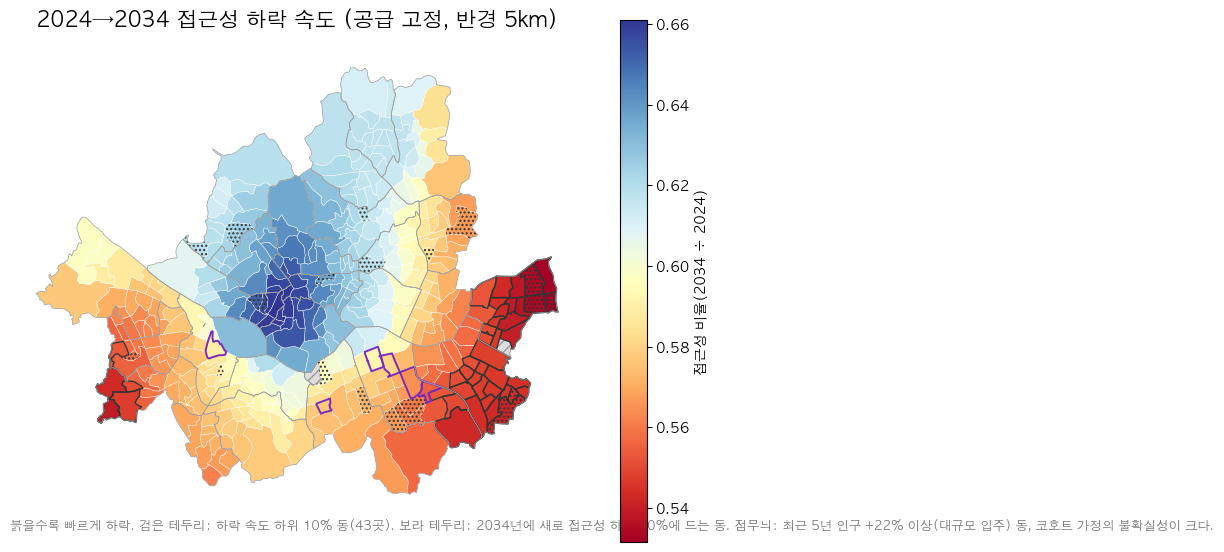

In [10]:
fig, ax = plt.subplots(figsize=(11, 9))
geo = dong.loc[seoul, ["행정동코드", "geometry"]].merge(table[["행정동코드", "하락비율", "소수요", "하락속도_상위10%", "새_하위10%", "견고한우선동", "지역"]], on="행정동코드")
geo.loc[~geo["소수요"]].plot(column="하락비율", ax=ax, cmap="RdYlBu", edgecolor="white", linewidth=0.3,
                           legend=True, legend_kwds={"shrink": 0.6, "label": f"접근성 비율({last} ÷ 2024)"})
geo.loc[geo["소수요"]].plot(ax=ax, color="#DDDDDD", edgecolor="#999999", hatch="///", linewidth=0.3)
geo.loc[geo["하락속도_상위10%"]].boundary.plot(ax=ax, color="#333333", linewidth=1.0)
geo.loc[geo["새_하위10%"]].boundary.plot(ax=ax, color="#7B2CBF", linewidth=1.4)
recent_geo = geo.loc[geo["행정동코드"].isin(recent_idx.map(dict(zip(elig.index, elig["행정동코드"]))))]
recent_geo.plot(ax=ax, facecolor="none", edgecolor="#333333", hatch="....", linewidth=0)
gu_shape = geo.dissolve(by="지역")
gu_shape.boundary.plot(ax=ax, color="#999999", linewidth=0.5)
ax.set_title(f"2024→{last} 접근성 하락 속도 (공급 고정, 반경 {k}km)", fontsize=15, pad=14)
ax.set_axis_off()
ax.text(0, -0.03, f"붉을수록 빠르게 하락. 검은 테두리: 하락 속도 하위 10% 동({n10}곳). 보라 테두리: {last}년에 새로 접근성 하위 10%에 드는 동. "
        f"점무늬: 최근 5년 인구 +{recent_thr:.0%} 이상(대규모 입주) 동, 코호트 가정의 불확실성이 크다.",
        transform=ax.transAxes, fontsize=9, color="#777777")
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "하락속도_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 8. 우선 동을 2034년에도 2024년 중앙값으로 유지하려면

06 노트북과 같은 greedy(정원 50석, 서울 평균 q, 동 중심점 후보지는 동마다 한 번, 견고한 우선 동 12곳의 제곱 부족을 가장 많이 줄이는 곳부터)를 2034년 수요에 적용해, 우선 동이 모두 2024년 서울 중앙값에 이를 때까지 필요한 시설 수를 구한다. 06 노트북의 2024년 결과와 나란히 단기·장기 규모로 정리한다.

In [11]:
NEW_CAPACITY = 50
new_supply = NEW_CAPACITY * seoul_q
eligible_mask = eligible
cand = dong.loc[eligible_mask, ["행정동코드", "행정동명", "cx", "cy"]].reset_index(drop=True)
dist_cand = E.distance_matrix_km(dong[["cx", "cy"]].to_numpy(), cand[["cx", "cy"]].to_numpy())
robust_mask = dong["행정동코드"].isin(robust).to_numpy()
reach = lambda a: bool((a[robust_mask] >= A_STAR - 1e-12).all())

scale = {}
for year in [C.BASE_YEAR] + C.FUTURE_YEARS:
    for per_site in (1, 2):
        try:
            chosen, acc_after = E.greedy_sites(acc[year], D[year], dist_cand, new_supply, k, A_STAR, robust_mask,
                                               decay=C.DECAY, objective="squared", stop=reach, max_per_site=per_site)
        except RuntimeError:  # 반경 안 후보지를 모두 써도 도달하지 못함
            scale[(year, per_site)] = None
            continue
        extra = np.column_stack([dist_cand[:, j] for j, *_ in chosen])
        full = E.e2sfca(D[year], np.concatenate([S, np.full(len(chosen), new_supply)]), np.hstack([dist, extra]), k, C.DECAY)
        assert np.allclose(full.accessibility, acc_after) and reach(acc_after)
        scale[(year, per_site)] = len(chosen)
assert scale[(C.BASE_YEAR, 1)] == 26  # 06 노트북 결과와 같다

fmt = lambda n: "도달 불가" if n is None else f"{n}곳 ({n * NEW_CAPACITY:,}석)"
years = [C.BASE_YEAR] + C.FUTURE_YEARS
scale_table = pd.DataFrame({
    "기준 연도 수요": years,
    "우선 동 부족 석수(추가 전)": [rob[f"부족_{y}"].sum() for y in years],
    "한 동에 1곳": [fmt(scale[(y, 1)]) for y in years],
    "한 동에 2곳까지": [fmt(scale[(y, 2)]) for y in years],
})
scale_table.to_csv(C.OUTPUT_DIR / "우선동_유지_규모.csv", index=False)
display(Markdown(
    "'도달 불가'는 동마다 한 곳씩 서울의 모든 후보지를 써도 우선 동이 2024년 중앙값에 닿지 않는다는 뜻이다. "
    "우선 동 반경 5km 안의 후보 동이 한정되어 있어, 수요가 늘면 같은 동에 시설을 더 모아야 한다."
))
display(scale_table.style.format({"우선 동 부족 석수(추가 전)": "{:,.0f}"}).hide(axis="index"))

'도달 불가'는 동마다 한 곳씩 서울의 모든 후보지를 써도 우선 동이 2024년 중앙값에 닿지 않는다는 뜻이다. 우선 동 반경 5km 안의 후보 동이 한정되어 있어, 수요가 늘면 같은 동에 시설을 더 모아야 한다.

기준 연도 수요,우선 동 부족 석수(추가 전),한 동에 1곳,한 동에 2곳까지
2024,295,"26곳 (1,300석)","24곳 (1,200석)"
2029,411,"43곳 (2,150석)","35곳 (1,750석)"
2034,541,도달 불가,"48곳 (2,400석)"


### 9. 지도

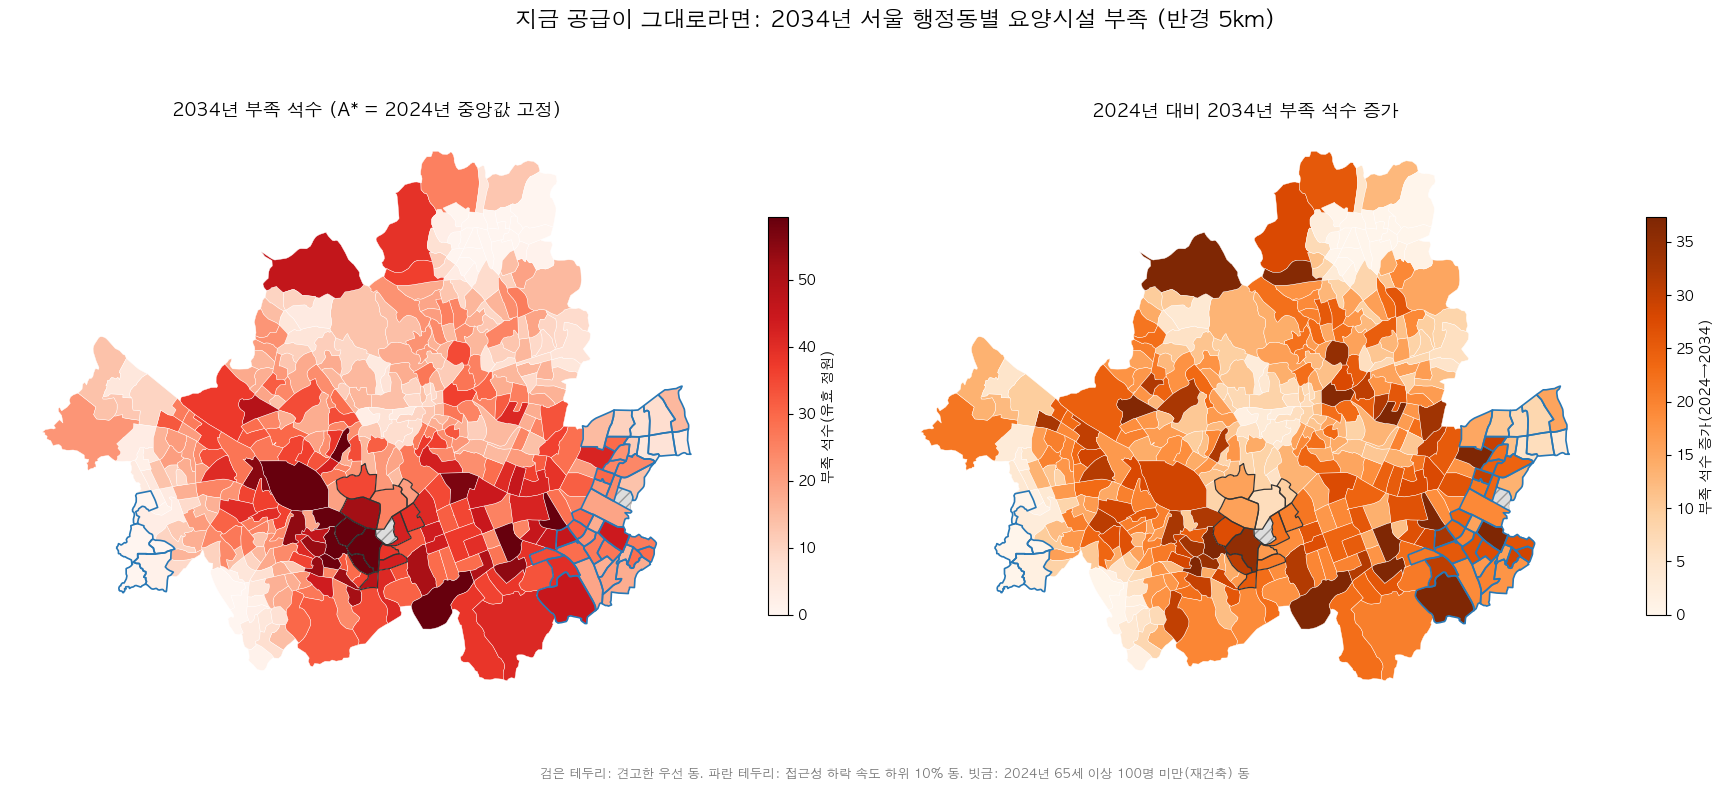

In [12]:
seoul_geo = dong.loc[seoul].copy()
seoul_geo = seoul_geo.merge(table[["행정동코드", f"부족_{C.BASE_YEAR}", f"부족_{last}", "견고한우선동", "소수요"]], on="행정동코드")
seoul_geo["증가"] = seoul_geo[f"부족_{last}"] - seoul_geo[f"부족_{C.BASE_YEAR}"]
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
vmax = seoul_geo[f"부족_{last}"].quantile(0.98)
seoul_geo.plot(column=f"부족_{last}", ax=axes[0], cmap="Reds", vmin=0, vmax=vmax, edgecolor="white", linewidth=0.3,
               legend=True, legend_kwds={"shrink": 0.6, "label": "부족 석수(유효 정원)"})
axes[0].set_title(f"{last}년 부족 석수 (A* = 2024년 중앙값 고정)", fontsize=13)
seoul_geo.plot(column="증가", ax=axes[1], cmap="Oranges", vmin=0, vmax=seoul_geo["증가"].quantile(0.98), edgecolor="white", linewidth=0.3,
               legend=True, legend_kwds={"shrink": 0.6, "label": f"부족 석수 증가(2024→{last})"})
axes[1].set_title(f"2024년 대비 {last}년 부족 석수 증가", fontsize=13)
for ax in axes:
    seoul_geo.loc[seoul_geo["소수요"]].plot(ax=ax, color="#DDDDDD", edgecolor="#999999", hatch="///", linewidth=0.3)
    seoul_geo.loc[seoul_geo["견고한우선동"]].boundary.plot(ax=ax, color="#333333", linewidth=0.9)
    seoul_geo.loc[seoul_geo["행정동코드"].isin(fast["행정동코드"])].boundary.plot(ax=ax, color="#2878B5", linewidth=1.2)
    ax.set_axis_off()
fig.suptitle(f"지금 공급이 그대로라면: {last}년 서울 행정동별 요양시설 부족 (반경 {k}km)", fontsize=16)
fig.text(0.5, 0.02, f"검은 테두리: 견고한 우선 동. 파란 테두리: 접근성 하락 속도 하위 10% 동. "
         "빗금: 2024년 65세 이상 100명 미만(재건축) 동", ha="center", fontsize=9, color="#777777")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(C.OUTPUT_DIR / "미래_부족석수_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 10. 보고서 문장

In [ ]:
first = min(C.FUTURE_YEARS)
g = summary
fast_gu = fast["지역"].value_counts()


In [1]:
from 검토_재계산 import reviewed_sentences

for sentence in reviewed_sentences("07"):
    print(sentence)


인정률·공급을 2024년 수준으로 고정한 시나리오의 서울 잠재 수요는 2029년 29,189명, 2034년 36,899명이다. 목표와 q를 고정한 정원 환산 하한은 각각 5,397석, 10,014석이다.
기존 2034년 순차 배치는 후보당 2곳에서 48곳 (2,400석)으로 목표에 도달한 실행 가능 해이며 최소를 증명한 값이 아니다. 서울 총량 보정은 동별 순이동을 검증하지 않는다. 2019→2024 인구 역검증·동별 이동·정비사업 시나리오는 후속 과제다.


### 해석상 주의

- 수요의 분모 기준: 이 분석의 서울 1~2등급 수요(2024년 22,074명)는 65세 이상 인정자만 센 값이다. 서론의 잔여정원 비율 6.3%는 전 연령 1~2등급 인정자(23,249명)를 분모로 쓰므로, 65세 미만 인정자 1,175명(5.1%)만큼 차이가 난다.
- 코호트 방식은 동 단위 전입·전출을 반영하지 못한다. 시도 합계는 장래인구추계로 맞췄지만, 시도 안에서 어느 동으로 사람이 옮겨 가는지는 2024년 연령 구조를 늙힌 결과를 따른다.
- 최근 5년 인구가 서울 상위 5%만큼 늘어난 대규모 입주 동(상일제1·2동, 고덕2동, 위례동, 거여2동 등)은 입주민이 그대로 머물며 늙는다는 코호트 가정의 불확실성이 크다. 이 동들의 수요 증가를 서울 중앙값으로 낮춰도 하락 속도 상위 10% 동은 대부분 유지되지만(7절), 동별 수치는 신중히 해석한다.
- 대규모 재개발·입주가 있는 동은 이 방식이 맞지 않는다. 예를 들어 둔촌1동(올림픽파크포레온, 2024년 11월 입주)과 반포본동은 2024년 7월 기준 고령인구가 거의 없어 미래 수요도 0에 가깝게 나오지만, 실제로는 입주 후 인구가 크게 늘어난다.
- 인정률은 2024년 수준으로 고정했다. 초고령 인구 안에서의 연령 구성 변화는 5세 연령군을 10세 단위로 묶은 인정률로만 반영된다.
- 공급은 2024년 7월 시설로 고정했다. 결과는 '지금 공급이 그대로라면'의 부족분이다.

### 출처

- 통계청, 시도별 간이생명표(5세별), KOSIS `DT_1B44` (2023)
- 통계청, 장래인구추계(시도편, 2022년 기준) 성 및 연령별 추계인구, KOSIS `DT_1BPB001` (중위 추계)
- 행정안전부 주민등록 인구통계(2024-07-31), 01~06 노트북 산출물